In [2]:
import json
import ssl
import urllib.parse
import urllib.request

import certifi

params = urllib.parse.urlencode(
    {
        "start": "1",
        "limit": "10",
        "convert": "USD",
    }
)

request = urllib.request.Request(
    f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
    headers={
        "Accept": "application/json",
        "X-CMC_PRO_API_KEY": "*********************",
    },
)

context = ssl.create_default_context(cafile=certifi.where())

with urllib.request.urlopen(request, context=context) as response:
    data = json.load(response)

print(data)

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20044915, 'total_supply': 20044915, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12659, 'cmc_rank': 1, 'last_updated': '2026-06-19T10:03:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1249613637168.97, 'quote': {'USD': {'price': 62340.6802757195, 'volume_24h': 29569088608.586292, 'cex_volume_24h': 29522841361.684116, 'dex_volume_24h': 46247246.90217511, 'volume_change_24h': -6.1223, 'percent_change_1h': -0.34188243, 'percent_change_24h': -2.77338591, 'percent_change_7d': -2.04008244, 'percent_change_30d': -19.51529069, 'percent_change_60d': -17.10746504, 'percent_change_90d': -11.74453081, 'market_cap': 1249613637168.9739, 'market_cap_dominance': 58.1182, 'fully_diluted_market_cap': 1309154285790.11, 'tvl': None, 'last_updated': 

In [3]:
type(data)

dict

In [4]:
import pandas as pd
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
#normalizes the data and makes it all pretty in a dataframe
df=pd.json_normalize(data['data'])
df['timestamp']=pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.004492e+07,2.004492e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12659,1,2026-06-19T10:03:00.000Z,None,NaN,NaN,NaN,1.249614e+12,"[mineable, pow, sha-256, store-of-value, state...",62340.680276,2.956909e+10,2.952284e+10,4.624725e+07,-6.1223,-0.341882,-2.773386,-2.040082,-19.515291,-17.107465,-11.744531,1.249614e+12,58.1182,1.309154e+12,None,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
1,1027,Ethereum,ETH,ethereum,True,1.206840e+08,1.206840e+08,NaN,2015-08-07T00:00:00.000Z,12091,2,2026-06-19T10:03:00.000Z,None,NaN,NaN,NaN,2.037013e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",1687.890653,1.194217e+10,1.185219e+10,8.997705e+07,-19.1234,-0.504125,-3.216796,0.622682,-20.726334,-27.040719,-21.766013,2.037013e+11,9.4746,2.037013e+11,None,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
2,825,Tether USDt,USDT,tether,True,1.864715e+11,1.931534e+11,NaN,2015-02-25T00:00:00.000Z,186432,3,2026-06-19T10:02:00.000Z,None,NaN,NaN,NaN,1.929654e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999027,6.340753e+10,6.182062e+10,1.586911e+09,-10.7713,0.007981,-0.001932,0.020986,0.005574,-0.121760,-0.087157,1.862899e+11,8.6645,1.929654e+11,None,2026-06-19T10:02:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-19 15:34:26.412476
3,1839,BNB,BNB,bnb,False,1.347835e+08,1.347835e+08,1.347835e+08,2017-07-25T00:00:00.000Z,3280,4,2026-06-19T10:03:00.000Z,None,NaN,NaN,NaN,7.700787e+10,"[marketplace, centralized-exchange, payments, ...",571.345014,1.048896e+09,1.026725e+09,2.217074e+07,-19.8082,-0.381411,-3.193169,-5.726847,-11.263381,-8.901537,-11.160224,7.700787e+10,3.5816,7.700787e+10,None,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
4,3408,USDC,USDC,usd-coin,False,7.492045e+10,7.492045e+10,NaN,2018-10-08T00:00:00.000Z,40508,5,2026-06-19T10:02:00.000Z,None,NaN,6.090122e+10,6.088969e+10,7.490626e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999811,1.011076e+10,7.976901e+09,2.133862e+09,-17.1391,0.007145,0.017967,0.012123,0.001513,0.016460,-0.018819,7.490626e+10,3.4838,7.490626e+10,None,2026-06-19T10:02:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-19 15:34:26.412476
5,52,XRP,XRP,xrp,False,6.205390e+10,9.998565e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1844,6,2026-06-19T10:02:00.000Z,None,NaN,NaN,NaN,1.124102e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.124263,1.848337e+09,1.847419e+09,9.177091e+05,-1.9109,-0.105964,-4.563148,-1.910400,-17.882586,-20.763734,-21.915315,6.976489e+10,3.2453,1.124263e+11,None,2026-06-19T10:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
6,5426,Solana,SOL,solana,True,5.801737e+08,6.286912e+08,NaN,2020-04-10T00:00:00.000Z,1141,7,2026-06-19T10:03:00.000Z,None,NaN,5.252369e+08,3.586005e+10,4.292329e+10,"[pos, platform, solana-ecosystem, cms-holdings...",68.274055,2.400985e+09,2.400962e+09,2.283802e+04,-2.2473,-0.473502,-4.873075,1.709786,-19.576186,-19.897954,-24.285996,3.961081e+10,1.8425,4.292329e+10,None,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
7,1958,TRON,TRX,tron,True,9.483442e+10,9.483442e+10,NaN,2017-09-13T00:00:00.000Z,1348,8,2026-06-19T10:03:

In [5]:
def api_runner():
    import json
    import ssl
    import urllib.parse
    import urllib.request
    
    import certifi
    
    params = urllib.parse.urlencode(
        {
            "start": "1",
            "limit": "10",
            "convert": "USD",
        }
    )
    
    request = urllib.request.Request(
        f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
        headers={
            "Accept": "application/json",
            "X-CMC_PRO_API_KEY": "*******************",
        },
    )
    
    context = ssl.create_default_context(cafile=certifi.where())
    
    with urllib.request.urlopen(request, context=context) as response:
        data = json.load(response)
    
    #print(data)

    
    df=pd.json_normalize(data['data'])
    df['timestamp']=pd.to_datetime('now')
    #df
    if not os.path.isfile(r'C:\Users\PC\Documents\My Tableau Repository\Workbooks\api.csv'):
        df.to_csv(r'C:\Users\PC\Documents\My Tableau Repository\Workbooks\api.csv',
                  header=True,index=False)
    else:
        df.to_csv(r'C:\Users\PC\Documents\My Tableau Repository\Workbooks\api.csv',
                  mode='a',header=False,index=False)
   
    
    

In [6]:
import os
from time import time
from time import sleep
for i in range(333):
    api_runner()
    print("Api runner completed")
    sleep(60)#sleep for  1 minute
exit()


Api runner completed


KeyboardInterrupt: 

In [7]:
df12=pd.read_csv(r'C:\Users\PC\Documents\My Tableau Repository\Workbooks\api.csv')
df12

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.004411e+07,2.004411e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12656,1,2026-06-17T17:41:00.000Z,NaN,NaN,NaN,NaN,1.320333e+12,"['mineable', 'pow', 'sha-256', 'store-of-value...",65871.343243,2.550594e+10,2.548348e+10,2.245577e+07,-3.4330,-0.013109,0.300564,6.867092,-14.013454,-13.210325,-5.354335,1.320333e+12,58.4712,1.383298e+12,NaN,2026-06-17T17:41:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-17 23:11:54.673434
1,1027,Ethereum,ETH,ethereum,True,1.206841e+08,1.206841e+08,NaN,2015-08-07T00:00:00.000Z,12088,2,2026-06-17T17:40:00.000Z,NaN,NaN,NaN,NaN,2.144471e+11,"['pos', 'smart-contracts', 'ethereum-ecosystem...",1776.929364,1.140439e+10,1.129807e+10,1.063232e+08,-26.1666,0.153853,-0.240895,9.453756,-15.551231,-24.802662,-16.126762,2.144471e+11,9.4973,2.144471e+11,NaN,2026-06-17T17:40:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-17 23:11:54.673434
2,825,Tether USDt,USDT,tether,True,1.865491e+11,1.931770e+11,NaN,2015-02-25T00:00:00.000Z,186122,3,2026-06-17T17:40:00.000Z,NaN,NaN,NaN,NaN,1.930026e+11,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.999097,6.079985e+10,5.922596e+10,1.573897e+09,-10.1879,-0.004309,0.010387,0.012491,-0.012492,-0.111188,-0.085467,1.863807e+11,8.2543,1.930026e+11,NaN,2026-06-17T17:40:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-17 23:11:54.673434
3,1839,BNB,BNB,bnb,False,1.347836e+08,1.347836e+08,1.347836e+08,2017-07-25T00:00:00.000Z,3278,4,2026-06-17T17:40:00.000Z,NaN,NaN,NaN,NaN,8.178729e+10,"['marketplace', 'centralized-exchange', 'payme...",606.804661,1.192281e+09,1.167197e+09,2.508430e+07,-13.0852,0.311237,0.403324,3.172583,-5.129611,-4.271123,-4.725517,8.178729e+10,3.6222,8.178729e+10,NaN,2026-06-17T17:40:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-17 23:11:54.673434
4,52,XRP,XRP,xrp,False,6.205390e+10,9.998565e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1844,5,2026-06-17T17:39:00.000Z,NaN,NaN,NaN,NaN,1.212384e+11,"['medium-of-exchange', 'enterprise-solutions',...",1.212558,1.590023e+09,1.588810e+09,1.213157e+06,-28.3180,-0.363433,-0.035073,9.635886,-12.100556,-15.407717,-15.296619,7.524395e+10,3.3331,1.212558e+11,NaN,2026-06-17T17:39:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-17 23:11:54.673434
5,3408,USDC,USDC,usd-coin,False,7.477875e+10,7.477875e+10,NaN,2018-10-08T00:00:00.000Z,40426,6,2026-06-17T17:40:00.000Z,NaN,NaN,6.090122e+10,6.087583e+10,7.474758e+10,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.999583,9.894438e+09,7.806894e+09,2.087544e+09,-2.4812,-0.013713,0.006187,-0.007172,-0.026004,-0.023753,-0.034027,7.474758e+10,3.3104,7.474758e+10,NaN,2026-06-17T17:40:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-17 23:11:54.673434
6,5426,Solana,SOL,solana,True,5.800565e+08,6.285620e+08,NaN,2020-04-10T00:00:00.000Z,1140,7,2026-06-17T17:39:00.000Z,NaN,NaN,5.252369e+08,3.873765e+10,4.635815e+10,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",73.752712,2.031984e+09,2.031980e+09,3.206470e+03,-14.2079,-0.359771,0.675698,15.605546,-12.459312,-15.025636,-15.886714,4.278074e+10,1.8950,4.635815e+10,NaN,2026-06-17T17:39:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-17 23:11:54.673434
7,1958,TRON,TRX,tron,True,9.483228e+10,9.483229e+10,NaN,2017-09-13T00:00:00.000Z,1348,8,2026-06-17T17:40:00.000Z,NaN,NaN,9.

In [9]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.004442e+07,2.004442e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12656,1,2026-06-18T10:51:00.000Z,None,NaN,NaN,NaN,1.282611e+12,"[mineable, pow, sha-256, store-of-value, state...",63988.417387,3.179788e+10,3.176208e+10,3.580246e+07,27.8650,-0.332356,-1.281423,1.575370,-16.736145,-14.934677,-9.340695,1.282611e+12,58.2238,1.343757e+12,None,2026-06-18T10:51:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-18 16:24:13.214141
1,1027,Ethereum,ETH,ethereum,True,1.206840e+08,1.206840e+08,NaN,2015-08-07T00:00:00.000Z,12089,2,2026-06-18T10:50:00.000Z,None,NaN,NaN,NaN,2.099962e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",1740.049832,1.452604e+10,1.438423e+10,1.418157e+08,15.4604,-0.342393,-1.684925,5.054347,-17.660816,-24.949923,-19.018136,2.099962e+11,9.5354,2.099962e+11,None,2026-06-18T10:50:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-18 16:24:13.214141
2,825,Tether USDt,USDT,tether,True,1.864718e+11,1.931534e+11,NaN,2015-02-25T00:00:00.000Z,186275,3,2026-06-18T10:50:00.000Z,None,NaN,NaN,NaN,1.929792e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999098,7.096475e+10,6.922624e+10,1.738514e+09,16.2693,0.001941,0.006363,0.024338,-0.013575,-0.096098,-0.087938,1.863037e+11,8.4572,1.929792e+11,None,2026-06-18T10:50:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-18 16:24:13.214141
3,1839,BNB,BNB,bnb,False,1.347835e+08,1.347835e+08,1.347835e+08,2017-07-25T00:00:00.000Z,3280,4,2026-06-18T10:51:00.000Z,None,NaN,NaN,NaN,7.938470e+10,"[marketplace, centralized-exchange, payments, ...",588.979240,1.311035e+09,1.281423e+09,2.961224e+07,5.7604,-0.295200,-2.138071,-1.738269,-7.807162,-5.070843,-8.433001,7.938470e+10,3.6036,7.938470e+10,None,2026-06-18T10:51:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-18 16:24:13.214141
4,3408,USDC,USDC,usd-coin,False,7.475242e+10,7.475242e+10,NaN,2018-10-08T00:00:00.000Z,40444,5,2026-06-18T10:50:00.000Z,None,NaN,6.090122e+10,6.088315e+10,7.473023e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999703,1.217832e+10,9.607112e+09,2.571209e+09,26.0445,0.008784,0.002178,-0.004070,-0.009536,0.006718,-0.024709,7.473023e+10,3.3924,7.473023e+10,None,2026-06-18T10:50:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-18 16:24:13.214141
5,52,XRP,XRP,xrp,False,6.205390e+10,9.998565e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1844,6,2026-06-18T10:51:00.000Z,None,NaN,NaN,NaN,1.168020e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.168187,1.907219e+09,1.905940e+09,1.279056e+06,14.7816,-0.995834,-2.409451,4.200764,-14.830365,-17.974280,-19.504788,7.249058e+10,3.2916,1.168187e+11,None,2026-06-18T10:51:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-18 16:24:13.214141
6,5426,Solana,SOL,solana,True,5.801745e+08,6.286919e+08,NaN,2020-04-10T00:00:00.000Z,1140,7,2026-06-18T10:51:00.000Z,None,NaN,5.252369e+08,3.735435e+10,4.471197e+10,"[pos, platform, solana-ecosystem, cms-holdings...",71.119059,2.474736e+09,2.474732e+09,4.773240e+03,19.6449,-1.058305,-1.610695,8.645169,-15.863453,-16.158259,-20.398674,4.126147e+10,1.8734,4.471197e+10,None,2026-06-18T10:51:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-18 16:24:13.214141
7,1958,TRON,TRX,tron,True,9.483335e+10,9.483335e+10,NaN,2017-09-13T00:00:00.000Z,1348,8,2026-06-18T10:51:00.000Z,

In [8]:
pd.set_option('display.float_format',lambda x: '%.5f' % x)

In [9]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20044915.00000,20044915.00000,21000000.00000,2010-07-13T00:00:00.000Z,12659,1,2026-06-19T10:03:00.000Z,None,NaN,NaN,NaN,1249613637168.96997,"[mineable, pow, sha-256, store-of-value, state...",62340.68028,29569088608.58629,29522841361.68412,46247246.90218,-6.12230,-0.34188,-2.77339,-2.04008,-19.51529,-17.10747,-11.74453,1249613637168.97388,58.11820,1309154285790.11011,None,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
1,1027,Ethereum,ETH,ethereum,True,120683971.13427,120683971.13427,NaN,2015-08-07T00:00:00.000Z,12091,2,2026-06-19T10:03:00.000Z,None,NaN,NaN,NaN,203701346867.88000,"[pos, smart-contracts, ethereum-ecosystem, coi...",1687.89065,11942166425.25019,11852189371.86366,89977053.38654,-19.12340,-0.50413,-3.21680,0.62268,-20.72633,-27.04072,-21.76601,203701346867.87921,9.47460,203701346867.88000,None,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
2,825,Tether USDt,USDT,tether,True,186471454928.25275,193153431960.50647,NaN,2015-02-25T00:00:00.000Z,186432,3,2026-06-19T10:02:00.000Z,None,NaN,NaN,NaN,192965414952.98001,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99903,63407532569.81711,61820621835.11392,1586910734.70335,-10.77130,0.00798,-0.00193,0.02099,0.00557,-0.12176,-0.08716,186289942207.56995,8.66450,192965414952.98001,None,2026-06-19T10:02:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-19 15:34:26.412476
3,1839,BNB,BNB,bnb,False,134783477.47000,134783477.47000,134783477.47000,2017-07-25T00:00:00.000Z,3280,4,2026-06-19T10:03:00.000Z,None,NaN,NaN,NaN,77007867863.91000,"[marketplace, centralized-exchange, payments, ...",571.34501,1048896153.57358,1026725412.38529,22170741.18830,-19.80820,-0.38141,-3.19317,-5.72685,-11.26338,-8.90154,-11.16022,77007867863.90778,3.58160,77007867863.91000,None,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
4,3408,USDC,USDC,usd-coin,False,74920452291.65910,74920452291.65910,NaN,2018-10-08T00:00:00.000Z,40508,5,2026-06-19T10:02:00.000Z,None,NaN,60901219650.23000,60889685086.45312,74906262514.50999,"[medium-of-exchange, stablecoin, asset-backed-...",0.99981,10110762456.04666,7976900585.37713,2133861870.66953,-17.13910,0.00714,0.01797,0.01212,0.00151,0.01646,-0.01882,74906262514.50662,3.48380,74906262514.50999,None,2026-06-19T10:02:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-19 15:34:26.412476
5,52,XRP,XRP,xrp,False,62053900985.00000,99985653167.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1844,6,2026-06-19T10:02:00.000Z,None,NaN,NaN,NaN,112410152083.42000,"[medium-of-exchange, enterprise-solutions, xrp...",1.12426,1848337167.13528,1847419458.00594,917709.12933,-1.91090,-0.10596,-4.56315,-1.91040,-17.88259,-20.76373,-21.91532,69764893523.69879,3.24530,112426281694.30000,None,2026-06-19T10:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:26.412476
6,5426,Solana,SOL,solana,True,580173744.69672,628691158.65400,NaN,2020-04-10T00:00:00.000Z,1141,7,2026-06-19T10:03:00.000Z,None,NaN,525236893.30000,35860052561.36594,42923294768.10000,"[pos, platform, solana-ecosystem, cms-holdings...",68.27406,2400985063.97851,2400962225.96283,22838.01569,-2.24730,-0.47350,-4.87307,1.70979,-19.5

In [13]:
df1=df.groupby('name',sort=False)[['quote.USD.volume_24h',
                                   'quote.USD.cex_volume_24h',
                                   'quote.USD.dex_volume_24h',
                                   'quote.USD.volume_change_24h',
                                   'quote.USD.volume_change_24h',
                                   'quote.USD.percent_change_1h',
                                   'quote.USD.percent_change_24h',
                                   'quote.USD.percent_change_7d',
                                   'quote.USD.percent_change_30d',
                                   'quote.USD.percent_change_60d',
                                   'quote.USD.percent_change_90d']].mean()
df1

,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,,,,,,
Bitcoin,29569088608.58629,29522841361.68412,46247246.90218,-6.12230,-6.12230,-0.34188,-2.77339,-2.04008,-19.51529,-17.10747,-11.74453
Ethereum,11942166425.25019,11852189371.86366,89977053.38654,-19.12340,-19.12340,-0.50413,-3.21680,0.62268,-20.72633,-27.04072,-21.76601
Tether USDt,63407532569.81711,61820621835.11392,1586910734.70335,-10.77130,-10.77130,0.00798,-0.00193,0.02099,0.00557,-0.12176,-0.08716
BNB,1048896153.57358,1026725412.38529,22170741.18830,-19.80820,-19.80820,-0.38141,-3.19317,-5.72685,-11.26338,-8.90154,-11.16022
USDC,10110762456.04666,7976900585.37713,2133861870.66953,-17.13910,-17.13910,0.00714,0.01797,0.01212,0.00151,0.01646,-0.01882
XRP,1848337167.13528,1847419458.00594,917709.12933,-1.91090,-1.91090,-0.10596,-4.56315,-1.91040,-17.88259,-20.76373,-21.91532
Solana,2400985063.97851,2400962225.96283,22838.01569,-2.24730,-2.24730,-0.47350,-4.87307,1.70979,-19.57619,-19.89795,-24.28600
TRON,480736790.88924,480649274.13354,87516.75570,-8.89450,-8.89450,0.33244,0.23294,2.93887,-9.92211,-2.66526,3.79557
Hyperliquid,1079643275.54478,896789191.47688,182854084.06790,-14.85970,-14.85970,-1.17811,-7.01287,12.54662,36.08463,62.42937,68.22521


In [14]:
df3=df1.stack()
df3

name                                     
Bitcoin      quote.USD.volume_24h           29569088608.58629
             quote.USD.cex_volume_24h       29522841361.68412
             quote.USD.dex_volume_24h          46247246.90218
             quote.USD.volume_change_24h             -6.12230
             quote.USD.volume_change_24h             -6.12230
             quote.USD.percent_change_1h             -0.34188
             quote.USD.percent_change_24h            -2.77339
             quote.USD.percent_change_7d             -2.04008
             quote.USD.percent_change_30d           -19.51529
             quote.USD.percent_change_60d           -17.10747
             quote.USD.percent_change_90d           -11.74453
Ethereum     quote.USD.volume_24h           11942166425.25019
             quote.USD.cex_volume_24h       11852189371.86366
             quote.USD.dex_volume_24h          89977053.38654
             quote.USD.volume_change_24h            -19.12340
             quote.USD.volum

In [15]:
type(df3)

pandas.core.series.Series

In [23]:
df5=df3.to_frame(name='values')
df5

values
name                                                      
Bitcoin     quote.USD.volume_24h         29569088608.58629
            quote.USD.cex_volume_24h     29522841361.68412
            quote.USD.dex_volume_24h        46247246.90218
            quote.USD.volume_change_24h           -6.12230
            quote.USD.volume_change_24h           -6.12230
            quote.USD.percent_change_1h           -0.34188
            quote.USD.percent_change_24h          -2.77339
            quote.USD.percent_change_7d           -2.04008
            quote.USD.percent_change_30d         -19.51529
            quote.USD.percent_change_60d         -17.10747
            quote.USD.percent_change_90d         -11.74453
Ethereum    quote.USD.volume_24h         11942166425.25019
            quote.USD.cex_volume_24h     11852189371.86366
            quote.USD.dex_volume_24h        89977053.38654
            quote.USD.volume_change_24h          -19.12340
            quote.USD.volume_change_24h          -19.12340
            quote.USD.percent_change_1h           -0.50413
            quote.USD.percent_change_24h          -3.21680
            quote.USD.percent_change_7d            0.62268
            quote.USD.percent_change_30d         -20.72633
            quote.USD.percent_change_60d         -27.04072
            quote.USD.percent_change_90d         -21.76601
Tether USDt quote.USD.volume_24h         63407532569.81711
            quote.USD.cex_volume_24h     61820621835.11392
            quote.USD.dex_volume_24h      1586910734.70335
            quote.USD.volume_change_24h          -10.77130
            quote.USD.volume_change_24h          -10.77130
            quote.USD.percent_change_1h            0.00798
            quote.USD.percent_change_24h          -0.00193
            quote.USD.percent_change_7d            0.02099
            quote.USD.percent_change_30d           0.00557
            quote.USD.percent_change_60d          -0.12176
            quote.USD.percent_change_90d          -0.08716
BNB         quote.USD.volume_24h          1048896153.57358
            quote.USD.cex_volume_24h      1026725412.38529
            quote.USD.dex_volume_24h        22170741.18830
            quote.USD.volume_change_24h          -19.80820
            quote.USD.volume_change_24h          -19.80820
            quote.USD.percent_change_1h           -0.38141
            quote.USD.percent_change_24h          -3.19317
            quote.USD.percent_change_7d           -5.72685
            quote.USD.percent_change_30d         -11.26338
            quote.USD.percent_change_60d          -8.90154
            quote.USD.percent_change_90d         -11.16022
USDC        quote.USD.volume_24h         10110762456.04666
            quote.USD.cex_volume_24h      7976900585.37713
            quote.USD.dex_volume_24h      2133861870.66953
            quote.USD.volume_change_24h          -17.13910
            quote.USD.volume_change_24h          -17.13910
            quote.USD.percent_change_1h            0.00714
            quote.USD.percent_change_24h           0.01797
            quote.USD.percent_change_7d            0.01212
            quote.USD.percent_change_30d           0.00151
            quote.USD.percent_change_60d           0.01646
            quote.USD.percent_change_90d          -0.01882
XRP         quote.USD.volume_24h          1848337167.13528
            quote.USD.cex_volume_24h      1847419458.00594
            quote.USD.dex_volume_24h          917709.12933
            quote.USD.volume_change_24h           -1.91090
            quote.USD.volume_change_24h           -1.91090
            quote.USD.percent_change_1h           -0.10596
            quote.USD.percent_change_24h          -4.56315
            quote.USD.percent_change_7d           -1.91040
            quote.USD.percent_change_30d         -17.88259
            quote.USD.percent_change_60d         -20.76373
            quote.USD.percent_change_90d         -21.91532
Solana      quote.USD.volume_24h        

In [17]:
type(df5)

pandas.core.frame.DataFrame

In [24]:
df5.dtypes

values    float64
dtype: object

In [25]:
len(df5)

110

In [27]:
index=pd.Index(range(110))
df6=df5.set_index(index)
df6


,values
0,29569088608.58629
1,29522841361.68412
2,46247246.90218
3,-6.12230
4,-6.12230
5,-0.34188
6,-2.77339
7,-2.04008
8,-19.51529
9,-17.10747


In [32]:
df7=df5.reset_index()
df7

,name,level_1,values
0,Bitcoin,quote.USD.volume_24h,29569088608.58629
1,Bitcoin,quote.USD.cex_volume_24h,29522841361.68412
2,Bitcoin,quote.USD.dex_volume_24h,46247246.90218
3,Bitcoin,quote.USD.volume_change_24h,-6.12230
4,Bitcoin,quote.USD.volume_change_24h,-6.12230
5,Bitcoin,quote.USD.percent_change_1h,-0.34188
6,Bitcoin,quote.USD.percent_change_24h,-2.77339
7,Bitcoin,quote.USD.percent_change_7d,-2.04008
8,Bitcoin,quote.USD.percent_change_30d,-19.51529
9,Bitcoin,quote.USD.percent_change_60d,-17.10747


In [35]:
df8=df7.rename(columns={'level_1': 'Percent change'})
df8

,name,Percent change,values
0,Bitcoin,quote.USD.volume_24h,29569088608.58629
1,Bitcoin,quote.USD.cex_volume_24h,29522841361.68412
2,Bitcoin,quote.USD.dex_volume_24h,46247246.90218
3,Bitcoin,quote.USD.volume_change_24h,-6.12230
4,Bitcoin,quote.USD.volume_change_24h,-6.12230
5,Bitcoin,quote.USD.percent_change_1h,-0.34188
6,Bitcoin,quote.USD.percent_change_24h,-2.77339
7,Bitcoin,quote.USD.percent_change_7d,-2.04008
8,Bitcoin,quote.USD.percent_change_30d,-19.51529
9,Bitcoin,quote.USD.percent_change_60d,-17.10747


In [44]:
df8['Percent change']=df8['Percent change'].replace(['quote.USD.volume_24h',
                                                     'quote.USD.cex_volume_24h',
                                                     'quote.USD.dex_volume_24h',
                                                     'quote.USD.volume_change_24h',
                                                     'quote.USD.percent_change_1h',
                                                     'quote.USD.percent_change_24h',
                                                     'quote.USD.percent_change_7d',
                                                     'quote.USD.percent_change_30d',
                                                     'quote.USD.percent_change_60d',
                                                     'quote.USD.percent_change_90d'],
                                                    ['24h','24h','24h','24h','1h','24h',
                                                     '7d','30d','60d','90d'])
df8
                                                     

,name,Percent change,values
0,Bitcoin,24h,29569088608.58629
1,Bitcoin,24h,29522841361.68412
2,Bitcoin,24h,46247246.90218
3,Bitcoin,24h,-6.12230
4,Bitcoin,24h,-6.12230
5,Bitcoin,1h,-0.34188
6,Bitcoin,24h,-2.77339
7,Bitcoin,7d,-2.04008
8,Bitcoin,30d,-19.51529
9,Bitcoin,60d,-17.10747


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

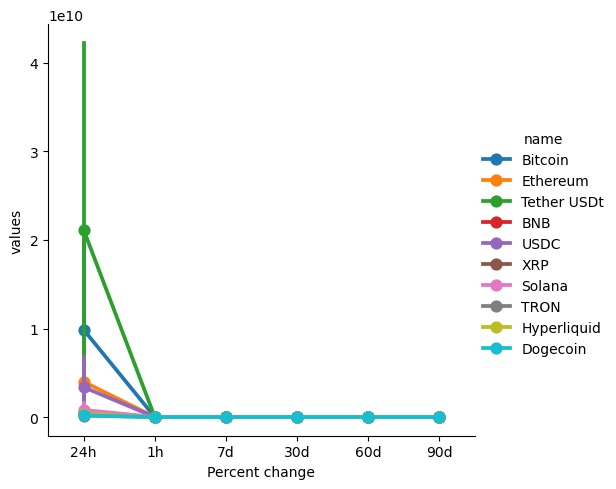

In [46]:
sns.catplot(x='Percent change',y='values',hue='name',data=df8,kind='point')

In [54]:
df9=df[['name','symbol','timestamp']]
df9=df12.query("name =='Bitcoin'")
df9

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20044112.00000,20044112.00000,21000000.00000,2010-07-13T00:00:00.000Z,12656,1,2026-06-17T17:41:00.000Z,NaN,NaN,NaN,NaN,1320332581558.83008,"['mineable', 'pow', 'sha-256', 'store-of-value...",65871.34324,25505939615.83119,25483483848.35308,22455767.47811,-3.43300,-0.01311,0.30056,6.86709,-14.01345,-13.21032,-5.35434,1320332581558.82886,58.47120,1383298208108.96997,NaN,2026-06-17T17:41:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-17 23:11:54.673434
10,1,Bitcoin,BTC,bitcoin,False,20044112.00000,20044112.00000,21000000.00000,2010-07-13T00:00:00.000Z,12656,1,2026-06-17T17:42:00.000Z,NaN,NaN,NaN,NaN,1320108614821.96997,"['mineable', 'pow', 'sha-256', 'store-of-value...",65860.16955,25592328154.23449,25569872396.31584,22455757.91865,-3.10610,-0.06959,0.27683,6.86429,-14.00264,-13.22711,-5.31125,1320108614821.97046,58.47140,1383063560573.87012,NaN,2026-06-17T17:42:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-17 23:12:55.659923
20,1,Bitcoin,BTC,bitcoin,False,20044112.00000,20044112.00000,21000000.00000,2010-07-13T00:00:00.000Z,12656,1,2026-06-17T17:43:00.000Z,NaN,NaN,NaN,NaN,1319155771823.51001,"['mineable', 'pow', 'sha-256', 'store-of-value...",65812.63225,25476838375.93442,25454387227.39275,22451148.54167,-3.33420,-0.20497,0.22071,6.57176,-14.11173,-13.29021,-5.40318,1319155771823.50513,58.43860,1382065277239.19995,NaN,2026-06-17T17:43:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-17 23:13:56.248528
30,1,Bitcoin,BTC,bitcoin,False,20044421.00000,20044421.00000,21000000.00000,2010-07-13T00:00:00.000Z,12656,1,2026-06-18T10:52:00.000Z,NaN,NaN,NaN,NaN,1282850809810.37988,"['mineable', 'pow', 'sha-256', 'store-of-value...",64000.39242,31807135860.23964,31771404790.56834,35731069.67130,27.79090,-0.31232,-1.22239,1.66775,-16.73885,-14.88618,-9.37077,1282850809810.37524,58.23470,1344008240797.66992,NaN,2026-06-18T10:52:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-18 16:24:22.781099
40,1,Bitcoin,BTC,bitcoin,False,20044915.00000,20044915.00000,21000000.00000,2010-07-13T00:00:00.000Z,12659,1,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,1249613637168.96997,"['mineable', 'pow', 'sha-256', 'store-of-value...",62340.68028,29569088608.58629,29522841361.68412,46247246.90218,-6.12230,-0.34188,-2.77339,-2.04008,-19.51529,-17.10747,-11.74453,1249613637168.97412,58.11820,1309154285790.11011,NaN,2026-06-19T10:03:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-19 15:34:34.757695


In [55]:
df12.shape
df12['name'].value_counts()

name
Bitcoin        5
Ethereum       5
Tether USDt    5
BNB            5
XRP            5
USDC           5
Solana         5
TRON           5
Hyperliquid    5
Dogecoin       5
Name: count, dtype: int64

<Axes: xlabel='name', ylabel='timestamp'>

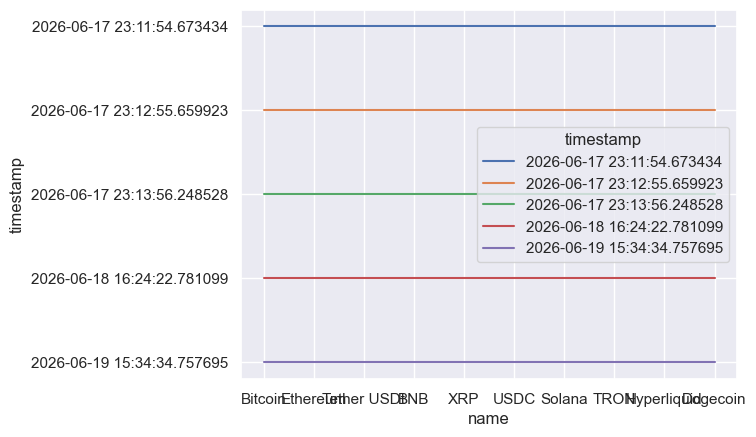

In [59]:
sns.set_theme(style="darkgrid")
sns.lineplot(x='name',y='timestamp',data=df12,hue='timestamp')